#  Iris Flower Classification

This notebook demonstrates a complete machine learning workflow for classifying iris flowers into three species using the K-Nearest Neighbors (KNN) algorithm.

**Workflow:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Model Training & Evaluation

In [ ]:
# Install required packages (uncomment if needed)
# %pip install pandas numpy scikit-learn matplotlib seaborn kaggle

In [1]:
# Create .kaggle directory (cross-platform) for authentication
import os

kaggle_dir = os.path.join(os.path.expanduser("~"), ".kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
print(f"✓ Ensured directory exists: {kaggle_dir}")

✓ Ensured directory exists: C:\Users\levie\.kaggle


In [2]:
# Import required libraries
import kaggle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from pandas.plotting import scatter_matrix

In [3]:
# Download the Iris dataset from Kaggle
api = KaggleApi()
api.authenticate()
handle = 'saurabh00007/iriscsv'

api.dataset_download_files(handle, path='./', unzip=True)
print(" Dataset downloaded successfully")

Dataset URL: https://www.kaggle.com/datasets/saurabh00007/iriscsv
 Dataset downloaded successfully


In [4]:
# Load and preview the dataset
iris = pd.read_csv('Iris.csv')
print(f"Dataset shape: {iris.shape}\n")
iris.head(5)

Dataset shape: (150, 6)



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Check dataset shape and info
print(f"Dataset Shape: {iris.shape}")
print("\nDataset Info:")
iris.info()

Dataset Shape: (150, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


##  Data Cleaning & Preprocessing

In [6]:
# Check for missing values and duplicates
print("Missing values per column:")
print(iris.isnull().sum())

print(f"\nDuplicate rows: {iris.duplicated().sum()}")

# Remove duplicates if any
iris = iris.drop_duplicates()
print("Duplicates removed")

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows: 0
Duplicates removed


In [7]:
# Examine species distribution
print("Species Distribution:")
iris["Species"].value_counts()

Species Distribution:


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
# Display statistical summary of the data
print("Statistical Summary:")
iris.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [9]:
# Remove unnecessary ID column
iris = iris.drop(['Id'], axis=1, inplace=False)
print("✓ ID column removed")
iris.head(2)

✓ ID column removed


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


##  Exploratory Data Analysis (EDA)

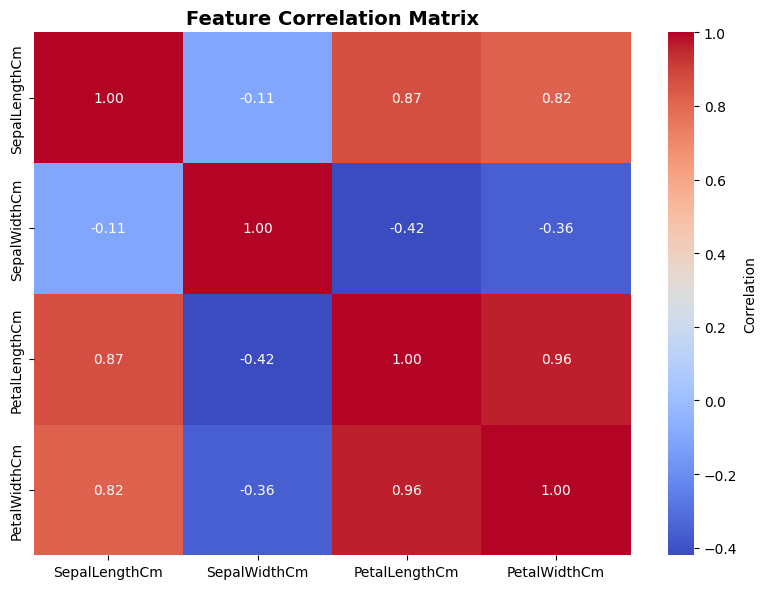

Strongest correlations:
PetalLengthCm  PetalWidthCm     0.962757
PetalWidthCm   PetalLengthCm    0.962757
SepalLengthCm  PetalLengthCm    0.871754
PetalLengthCm  SepalLengthCm    0.871754
dtype: float64


In [10]:
# Correlation matrix heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = iris.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Strongest correlations:\n{correlation_matrix.unstack().sort_values(ascending=False)[4:8]}")

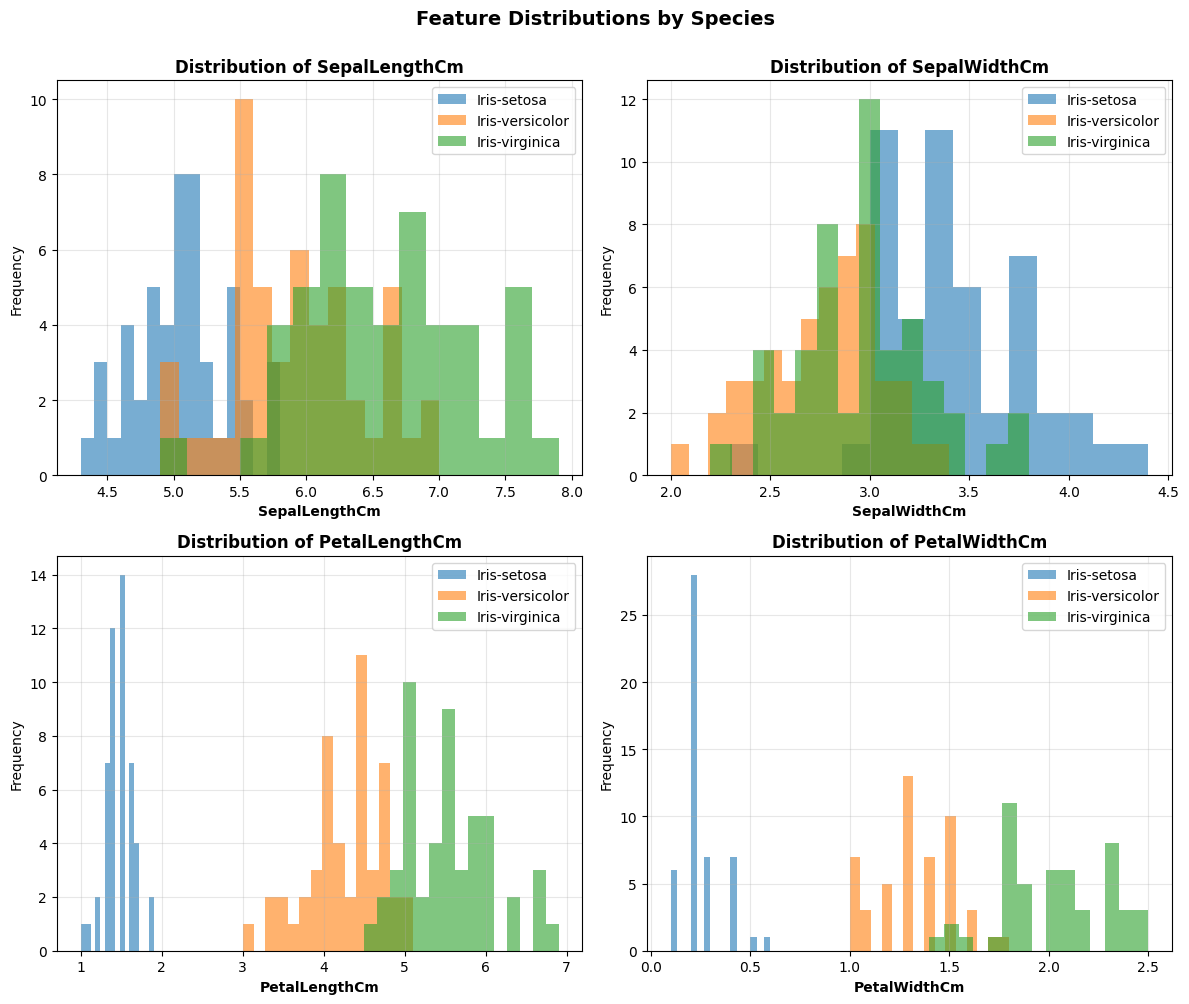

In [11]:
# Distribution of features by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    for species in iris['Species'].unique():
        data = iris[iris['Species'] == species][feature]
        ax.hist(data, alpha=0.6, label=species, bins=15)
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

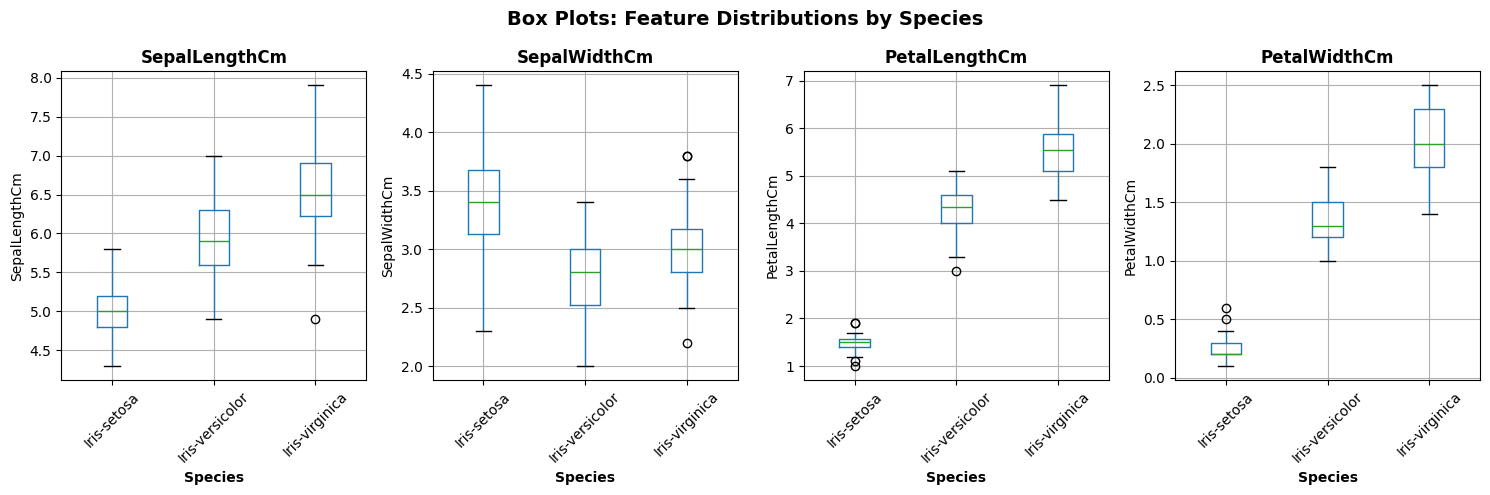

In [12]:
# Box plots for outlier detection
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for idx, feature in enumerate(features):
    ax = axes[idx]
    iris.boxplot(column=feature, by='Species', ax=ax)
    ax.set_xlabel('Species', fontweight='bold')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature}', fontweight='bold')
    plt.sca(ax)
    plt.xticks(rotation=45)

fig.suptitle('Box Plots: Feature Distributions by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

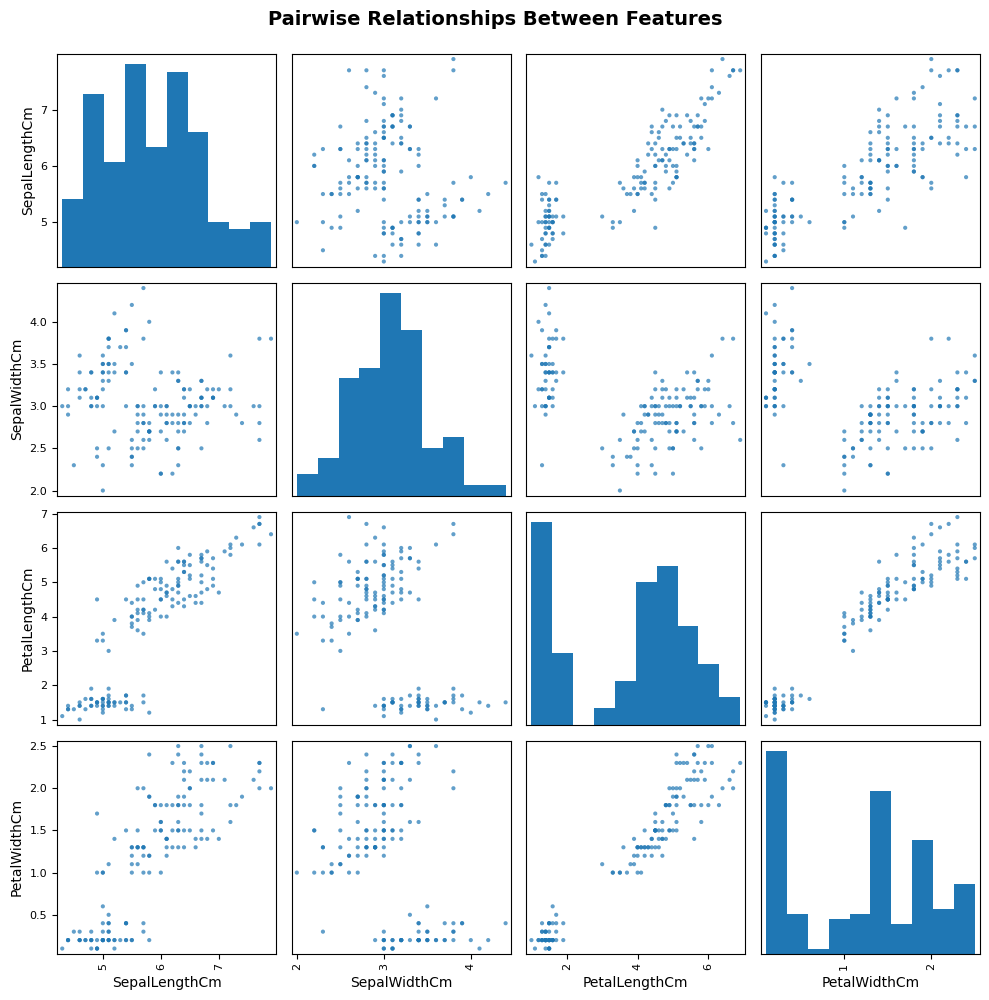


EDA SUMMARY
Total samples: 150
Features: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
Target variable: Species
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [13]:
# Pairplot to visualize relationships between features
scatter_matrix(iris[features], alpha=0.7, figsize=(10, 10), diagonal='hist')
plt.suptitle('Pairwise Relationships Between Features', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("EDA SUMMARY")
print("="*50)
print(f"Total samples: {len(iris)}")
print(f"Features: {', '.join(features)}")
print(f"Target variable: Species")
print(f"Classes: {iris['Species'].unique().tolist()}")
print("="*50)

##  Model Training & Evaluation

### Step 1: Data Preparation

In [14]:
# Prepare data for modeling
# Encode target variable (Species) from categorical to numerical
le = LabelEncoder()
iris_copy = iris.copy()
iris_copy["Species"] = le.fit_transform(iris["Species"])

# Display the encoding
print("Species Encoding:")
for i, class_name in enumerate(le.classes_):
    print(f"  {i}: {class_name}")
print()

Species Encoding:
  0: Iris-setosa
  1: Iris-versicolor
  2: Iris-virginica



In [15]:
#Encoding the string to numerical values
le = LabelEncoder()

iris["Species"] = le.fit_transform(iris["Species"])

In [16]:
#Splitting the data to input features and target features
X = iris.iloc[:,:4]
y = iris.iloc[:,4]

In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state= 42,test_size = 0.3)

In [18]:
#Standardising the values
scaler = MinMaxScaler(feature_range = (0,1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


In [19]:
#Train your model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 8,metric = 'euclidean')
knn.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=8)

In [20]:
### Step 3: Model Evaluation

# Make predictions on test set
y_pred = knn.predict(X_test)
print("Predictions generated on test set")

Predictions generated on test set


In [21]:
# Calculate model accuracy
accuracy = knn.score(X_test, y_test)
print("\n" + "="*50)
print(f"MODEL ACCURACY: {accuracy:.2%}")
print("="*50)


MODEL ACCURACY: 100.00%



CONFUSION MATRIX:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



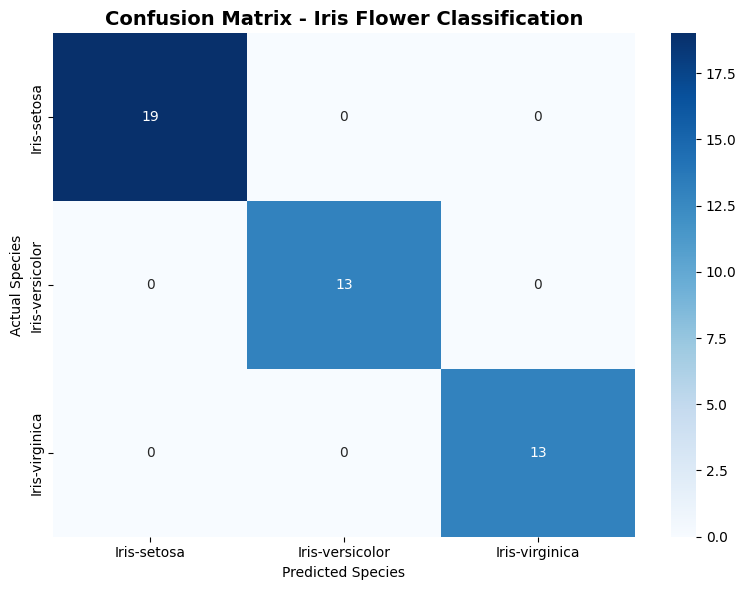

In [22]:
# Detailed evaluation metrics
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names=le.classes_)

print("\nCONFUSION MATRIX:")
print(cm)
print("\nCLASSIFICATION REPORT:")
print(cr)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Iris Flower Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.tight_layout()
plt.show()